In [2]:
import os
import json

# Workaround for Ray on Windows inside IDE/Jupyter job objects.
# Must be set before importing ray.
os.environ["RAY_DISABLE_WINDOWS_JOB_OBJECT"] = "1"

from datetime import datetime

import torch
import torch.nn as nn
import pandas as pd
import numpy as np

from torch.utils.data import DataLoader
from torch.utils.data import Dataset

from sklearn.model_selection import TimeSeriesSplit

from optuna.samplers import TPESampler
from optuna.pruners import SuccessiveHalvingPruner

from model import TCNRegressor
from tuning import ray_train
from ray import tune
from ray.tune import RunConfig
from ray.tune import Tuner
from ray.tune.schedulers import ASHAScheduler
from ray.tune.search.optuna import OptunaSearch
from ray.tune import CLIReporter


import train
import utils
import tuning
import data
from data import transform_data
from data import TimeSeriesDataset
from data import transform_with_scaler

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

C:\Users\Jojie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-20 12:28:25,667	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-02-20 12:28:31,918	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [4]:
import torch

print(f"PyTorch version: {torch.__version__}")

has_xpu_attr = hasattr(torch, "xpu")
xpu_compiled = hasattr(torch._C, "_xpu_getDeviceCount")
xpu_available = has_xpu_attr and torch.xpu.is_available()

print(f"XPU compiled: {xpu_compiled}")
print(f"XPU available: {xpu_available}")

if xpu_available:
    print(f"Device count: {torch.xpu.device_count()}")
    print(f"Device name: {torch.xpu.get_device_name(0)}")
    test_device = "xpu"
else:
    print("Device count: 0")
    print("Device name: N/A")
    test_device = "cuda" if torch.cuda.is_available() else "cpu"

# Test tensor creation
x = torch.randn(3, 3, device=test_device)
print(f"Test tensor: {x.size()} {x.device}")

PyTorch version: 2.6.0+cpu
XPU compiled: False
XPU available: False
Device count: 0
Device name: N/A
Test tensor: torch.Size([3, 3]) cpu


In [ ]:
# IMPORTANT: Complete clean uninstall first
pip uninstall -y torch torchvision torchaudio intel-cmplr-lib-rt intel-cmplr-lib-ur intel-cmplr-lic-rt intel-sycl-rt pytorch-triton-xpu tcmlib umf intel-pti

# Fresh install with all Intel runtime dependencies
pip install torch==2.7.1+xpu torchvision==0.22.1+xpu torchaudio==2.7.1+xpu intel-cmplr-lib-rt intel-cmplr-lib-ur intel-cmplr-lic-rt intel-sycl-rt pytorch-triton-xpu tcmlib umf intel-pti --index-url https://download.pytorch.org/whl/xpu --extra-index-url https://pypi.org/simple

In [3]:
# Ray Windows fallback: ignore only AssignProcessToJobObject WinError 203
if os.name == "nt":
    import ray._private.utils as ray_private_utils

    _original_set_kill = ray_private_utils.set_kill_child_on_death_win32

    def _safe_set_kill_child_on_death_win32(child_proc):
        try:
            _original_set_kill(child_proc)
        except OSError as exc:
            if getattr(exc, "errno", None) == 203 or "AssignProcessToJobObject" in str(exc):
                return
            raise

    ray_private_utils.set_kill_child_on_death_win32 = _safe_set_kill_child_on_death_win32


In [3]:
# # Number of trials for tuning
# trials = 100

# # Fixed parameters (not tuned)
# fixed_params = {
#     "lag_periods": [1, 3, 6, 12],
#     "features": ['BIR', 'BOC', 'Other Offices', 'TotalTrade_PHPMN', 'NominalGDP_disagg', 'Pop_disagg', 'USDPHP'],
#     "labels": ["BIR", 'BOC', 'Other Offices', 'Expenditures', 'Non-Tax Revenues' ],
#     "dummy_vars": ['COVID-19', 'TRAIN', 'CREATE', 'FIST', 'BIR_COMM'],
#     "experiment_name": "test"
# }

# # Resource detection (equivalent to your resources setup)
# if torch.cuda.is_available():
#     device = "cuda"
#     n_jobs = 4  # Run 4 trials concurrently (equivalent to max_concurrent_trials=4)
#     print("Using CUDA GPU")
# elif torch.backends.mps.is_available():
#     device = "mps"
#     n_jobs = 1
#     print("Using MPS (Mac GPU) - GPU allocation not specified")
# else:
#     device = "cpu"
#     n_jobs = 4
#     print("Using CPU only")

# def objective(trial):
#     """
#     Optuna objective function - equivalent to ray_train_with_resources
#     Replace the train_model call with your actual ray_train function
#     """
    
#     # Define search space (same as your Ray Tune search_space)
#     config = {
#         # === MODEL ARCHITECTURE ===
#             # === MODEL ARCHITECTURE ===
#         "num_channels": trial.suggest_categorical("num_channels", [[64], [64, 64], [64, 64, 64], [128], [128, 128], [128, 128, 128], [256], [256, 256], [256, 256, 256]]),
#         "kernel_size": trial.suggest_categorical("kernel_size", [2, 3, 4, 5]),
#         "dropout": trial.suggest_float("dropout", 0.1, 0.4),
#         "output_size": 3,  # Fixed: number of output variables (BIR, BOC, Other Offices)
        
#         # === OPTIMIZER ===
#         "lr": trial.suggest_float("lr", 5e-4, 5e-2, log=True),
#         "wd": trial.suggest_float("wd", 1e-6, 1e-4, log=True),
        
#         # === SCHEDULER ===
#         "factor": trial.suggest_float("factor", 0.2, 0.5),
#         "patience": trial.suggest_categorical("patience", [5, 10]),
        
#         # === TRAINING ===
#         "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64]),
#         "seq_len": trial.suggest_categorical("seq_len", [12, 18, 24]),
#         "l1_lambda": trial.suggest_float("l1_lambda", 1e-5, 1e-2, log=True),
        
#         # === DEVICE ===
#         "device": device,
#     }
    
#     # Add fixed parameters
#     config.update(fixed_params)
    
#     try:
#         # REPLACE THIS with your actual ray_train function call
#         # Your ray_train should accept config and optionally trial for intermediate reporting
#         result = ray_train(config, trial=trial)
        
#         # Handle result (loss, std) or just loss
#         if isinstance(result, tuple):
#             loss, std = result
#             trial.set_user_attr("std", std)
#         else:
#             loss = result
#             trial.set_user_attr("std", None)
        
#         return loss
    
#     except optuna.TrialPruned:
#         raise
#     except Exception as e:
#         print(f"Trial {trial.number} failed: {str(e)}")
#         return float('inf')

# # ASHA Scheduler equivalent (same parameters as your ASHAScheduler)
# # max_t=50, grace_period=10, reduction_factor=2
# pruner = SuccessiveHalvingPruner(
#     min_resource=10,        # grace_period
#     reduction_factor=2,     # reduction_factor
#     min_early_stopping_rate=0
# )

# # Optuna Search (TPE sampler - same as OptunaSearch)
# sampler = TPESampler(
#     seed=42,
#     n_startup_trials=10,
#     multivariate=True
# )

# # Create study (equivalent to creating Tuner)
# study = optuna.create_study(
#     direction="minimize",  # mode="min"
#     sampler=sampler,
#     pruner=pruner,
#     study_name="tcn_tuning"
# )

# # Progress reporter (equivalent to CLIReporter)
# class ProgressReporter:
#     def __init__(self, max_trials, metric_columns=None):
#         self.max_trials = max_trials
#         self.metric_columns = metric_columns or ["loss", "std"]
#         self.trials_completed = 0
#         self.trials_running = 0
#         self.best_loss = float('inf')
#         self.recent_trials = []
        
#     def __call__(self, study, trial):
#         self.trials_completed += 1
        
#         # Update best loss
#         if study.best_value < self.best_loss:
#             self.best_loss = study.best_value
        
#         # Get trial info
#         state = trial.state.name
#         loss = trial.value if trial.value is not None else float('inf')
#         std = trial.user_attrs.get("std", None)
        
#         # Store recent trial info
#         trial_info = {
#             'trial_number': trial.number,
#             'state': state,
#             'loss': loss,
#             'std': std,
#             'params': trial.params
#         }
#         self.recent_trials.append(trial_info)
        
#         # Keep only last 15 trials (max_progress_rows=15)
#         if len(self.recent_trials) > 15:
#             self.recent_trials.pop(0)
        
#         # Print intermediate table (similar to CLIReporter)
#         if self.trials_completed % 5 == 0 or self.trials_completed == 1:
#             self._print_table()
    
#     def _print_table(self):
#         print("\n" + "="*100)
#         print(f"Progress: {self.trials_completed}/{self.max_trials} trials | Best loss: {self.best_loss:.4f}")
#         print("="*100)
        
#         # Header
#         print(f"{'Trial':<8} {'State':<12} {'Loss':<12} {'Std':<12} {'hidden_size':<12} {'lr':<12} {'batch_size':<12}")
#         print("-"*100)
        
#         # Sorted by loss (sort_by_metric=True)
#         sorted_trials = sorted(
#             [t for t in self.recent_trials if t['loss'] != float('inf')],
#             key=lambda x: x['loss']
#         )
        
#         for t in sorted_trials[:15]:  # max_progress_rows=15
#             loss_str = f"{t['loss']:.4f}" if t['loss'] != float('inf') else "N/A"
#             std_str = f"{t['std']:.4f}" if t['std'] is not None else "N/A"
#             hidden_size = t['params'].get('hidden_size', 'N/A')
#             lr = f"{t['params'].get('lr', 0):.2e}" if 'lr' in t['params'] else "N/A"
#             batch_size = t['params'].get('batch_size', 'N/A')
            
#             print(f"{t['trial_number']:<8} {t['state']:<12} {loss_str:<12} {std_str:<12} {hidden_size:<12} {lr:<12} {batch_size:<12}")
        
#         print("="*100 + "\n")

# # Statistics tracker (prints every 30 seconds worth of trials)
# class StatsTracker:
#     def __init__(self):
#         self.start_time = datetime.now()
#         self.last_report_time = self.start_time
        
#     def __call__(self, study, trial):
#         current_time = datetime.now()
#         elapsed_since_report = (current_time - self.last_report_time).total_seconds()
        
#         # Report every ~30 seconds (max_report_frequency=30)
#         if elapsed_since_report >= 30:
#             self.last_report_time = current_time
            
#             completed = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
#             pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
#             failed = len([t for t in study.trials if t.state == optuna.trial.TrialState.FAIL])
            
#             total_elapsed = (current_time - self.start_time).total_seconds()
            
#             print(f"\n{'#'*100}")
#             print(f"STATUS UPDATE (after {total_elapsed/60:.1f} minutes)")
#             print(f"{'#'*100}")
#             print(f"Completed: {completed} | Pruned: {pruned} | Failed: {failed}")
#             if completed > 0:
#                 print(f"Best loss so far: {study.best_value:.4f}")
#                 print(f"Average time per trial: {total_elapsed/trial.number:.1f}s")
#             print(f"{'#'*100}\n")

# # Initialize reporters
# reporter = ProgressReporter(max_trials=trials, metric_columns=["loss", "std"])
# stats_tracker = StatsTracker()

# # Run optimization (equivalent to tuner.fit())
# print("="*100)
# print("STARTING HYPERPARAMETER TUNING")
# print("="*100)
# print(f"Total trials: {trials}")
# print(f"Concurrent trials: {n_jobs}")
# print(f"Device: {device}")
# print(f"Study name: tcn_tuning")
# print(f"Storage: ray_results/ (Optuna equivalent)")
# print("="*100 + "\n")

# # Create results directory (equivalent to storage_path)
# results_dir = os.path.abspath("ray_results/tcn_tuning")
# os.makedirs(results_dir, exist_ok=True)

# # Optimize
# study.optimize(
#     objective,
#     n_trials=trials,
#     callbacks=[reporter, stats_tracker],
#     n_jobs=n_jobs,  # max_concurrent_trials=4
#     show_progress_bar=True,
#     gc_after_trial=True
# )

# # Get best result (equivalent to results.get_best_result)
# best_trial = study.best_trial
# best_config = best_trial.params.copy()
# best_config.update(fixed_params)  # Add fixed params

# # Print results (same format as your original code)
# print("\n" + "="*50)
# print("Best Hyperparameters:")
# print("="*50)
# for key, value in best_config.items():
#     print(f"{key}: {value}")
# print(f"\nBest CV Loss: {best_trial.value:.4f}")

# # Save to exp_folder (same structure as your original code)
# exp_name = best_config.get('experiment_name', 'default')
# exp_folder = f"configs/{exp_name}"
# os.makedirs(exp_folder, exist_ok=True)

# # Save best config (same path as your original code)
# config_path = f"{exp_folder}/best_config.json"
# with open(config_path, "w") as f:
#     json.dump(best_config, f, indent=4)

# print(f"\nConfig saved to: {config_path}")

# # Save metadata (same structure as your original code)
# metadata = {
#     'best_loss': best_trial.value,
#     'best_std': best_trial.user_attrs.get('std', None),
#     'num_trials': len(study.trials),
#     'num_completed': len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]),
#     'num_pruned': len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]),
#     'num_failed': len([t for t in study.trials if t.state == optuna.trial.TrialState.FAIL]),
#     'timestamp': pd.Timestamp.now().isoformat()
# }
# metadata_path = f"{exp_folder}/metadata.json"
# with open(metadata_path, "w") as f:
#     json.dump(metadata, f, indent=4)

# print(f"Metadata saved to: {metadata_path}")

# # Save study results to ray_results directory
# study_results_path = f"{results_dir}/study.pkl"
# import joblib
# joblib.dump(study, study_results_path)

# # Save trials dataframe
# trials_df = study.trials_dataframe()
# trials_df.to_csv(f"{results_dir}/trials.csv", index=False)

# print(f"\nStudy results saved to: {results_dir}/")
# print("  - study.pkl (complete study object)")
# print("  - trials.csv (all trial results)")

# # Optional: Generate visualizations
# try:
#     import plotly
    
#     fig1 = optuna.visualization.plot_optimization_history(study)
#     fig1.write_html(f"{exp_folder}/optimization_history.html")
    
#     fig2 = optuna.visualization.plot_param_importances(study)
#     fig2.write_html(f"{exp_folder}/param_importances.html")
    
#     fig3 = optuna.visualization.plot_parallel_coordinate(study)
#     fig3.write_html(f"{exp_folder}/parallel_coordinate.html")
    
#     print(f"\nVisualizations saved to {exp_folder}/")
    
# except ImportError:
#     print("\nInstall plotly for visualizations: pip install plotly kaleido")

# print("\n" + "="*50)
# print("TUNING COMPLETE")
# print("="*50)

In [ ]:
# ============================================================
# EXPERIMENT LOOP — 2 Targets × 4 Feature Configurations
# ============================================================

trials = 50

reporter = CLIReporter(
    metric="loss",
    mode="min",
    metric_columns=["loss", "std"],
    max_progress_rows=15,
    print_intermediate_tables=True,
    max_report_frequency=30,
    sort_by_metric=True
)

def trial_dirname_creator(trial):
    return f"trial_{trial.trial_id}"

# ---------- Target Definitions ----------
TARGETS = {
    "aggregated": {
        "features": ["Non-tax Revenues", "Expenditures","Tax Revenues", "TotalTrade_PHPMN", "NominalGDP_disagg", "Pop_disagg", "USDPHP"],
        "labels":   ["Tax Revenues","Non-tax Revenues", "Expenditures"],
        # BIR+BOC+Others collapsed into one "Tax Revenues" column in your cordata.csv
        # If you have an aggregated tax col, add it to features/labels above
    },
    "disaggregated": {
        "features": ["BIR", "BOC", "Other Offices", "Non-tax Revenues", "Expenditures",
                     "TotalTrade_PHPMN", "NominalGDP_disagg", "Pop_disagg", "USDPHP"],
        "labels":   ["BIR", "BOC", "Other Offices", "Non-tax Revenues", "Expenditures"],
    },
}

# ---------- Feature Configurations ----------
FEATURE_CONFIGS = {
    # Config 1: All numerical + lagged + dummy
    "num_lag_dummy": {
        "dummy_vars":    ["COVID-19", "TRAIN", "CREATE", "FIST", "BIR_COMM"],
        "use_seasonal":  False,
    },
    # Config 2: All numerical + lagged + COVID-19 only
    "num_lag_covid": {
        "dummy_vars":    ["COVID-19"],
        "use_seasonal":  False,
    },
    # Config 3: All numerical + lagged + dummy + seasonal
    "num_lag_dummy_seasonal": {
        "dummy_vars":    ["COVID-19", "TRAIN", "CREATE", "FIST", "BIR_COMM"],
        "use_seasonal":  True,
    },
    # Config 4: All numerical + lagged + COVID-19 + seasonal
    "num_lag_covid_seasonal": {
        "dummy_vars":    ["COVID-19"],
        "use_seasonal":  True,
    },
}

BASE_SEARCH_SPACE = {
    "num_channels":  tune.choice([[64], [64, 64], [64, 64, 64], [128], [128, 128], [128, 128, 128], [256], [256, 256], [256, 256, 256]]),
    "kernel_size":   tune.choice([2, 3, 4, 5]),
    "dropout":       tune.uniform(0.1, 0.4),
    "lr":            tune.loguniform(5e-4, 5e-2),
    "wd":            tune.loguniform(1e-6, 1e-4),
    "factor":        tune.uniform(0.2, 0.5),
    "patience":      tune.choice([5, 10]),
    "batch_size":    tune.choice([16, 32, 64]),
    "seq_len":       tune.choice([12, 18, 24]),
    "l1_lambda":     tune.loguniform(1e-5, 1e-2),
    "lag_periods":   [1, 3, 6, 12]
}

all_results = {}   # stores best_result per (target, config)

for target_name, target_cfg in TARGETS.items():
    for config_name, feat_cfg in FEATURE_CONFIGS.items():

        exp_name = f"{target_name}__{config_name}"
        print(f"\n{'='*60}")
        print(f"  EXPERIMENT: {exp_name}")
        print(f"{'='*60}")

        # Build the full param space for this experiment
        search_space = {
            **BASE_SEARCH_SPACE,
            # Data columns — fixed per experiment, not tuned
            "features":         target_cfg["features"],
            "labels":           target_cfg["labels"],
            "dummy_vars":       feat_cfg["dummy_vars"],
            "use_seasonal":     feat_cfg["use_seasonal"],
            "experiment_name":  exp_name
        }

        # ---- Ray Tune setup (same as your existing code) ----
        scheduler = ASHAScheduler(
            metric="loss", mode="min",
            max_t=50, grace_period=10, reduction_factor=2
        )
        search_alg = OptunaSearch(metric="loss", mode="min")

        resources = {"cpu": 5}
        if torch.cuda.is_available():
            resources["gpu"] = 0.25

        ray_train_with_resources = tune.with_resources(ray_train, resources=resources)

        tuner = Tuner(
            ray_train_with_resources,
            tune_config=tune.TuneConfig(
                search_alg=search_alg,
                scheduler=scheduler,
                num_samples=trials,
                trial_dirname_creator=trial_dirname_creator,
                max_concurrent_trials=4,
            ),
            run_config=RunConfig(
                name=f"tcn_{exp_name}",
                storage_path=os.path.abspath("ray_results"),
                verbose=1,
                progress_reporter=reporter,
            ),
            param_space=search_space,
        )

        results = tuner.fit()

        best_result = results.get_best_result(metric="loss", mode="min")
        best_config = best_result.config
        best_metrics = best_result.metrics

        per_label_metrics = {k: v for k, v in best_metrics.items() if k.startswith("loss_")}

        # ---- Save config ----
        exp_folder = f"configs/{exp_name}"
        os.makedirs(exp_folder, exist_ok=True)

        with open(f"{exp_folder}/best_config.json", "w") as f:
            json.dump(best_config, f, indent=4)

        metadata = {
            "target":     target_name,
            "config":     config_name,
            "best_loss":  best_result.metrics["loss"],
            "per_label_mape":  per_label_metrics,
            "best_std":   best_result.metrics.get("std", None),
            "num_trials": len(results),
            "timestamp":  pd.Timestamp.now().isoformat(),
        }
        with open(f"{exp_folder}/metadata.json", "w") as f:
            json.dump(metadata, f, indent=4)

        all_results[(target_name, config_name)] = {
            "best_loss":   best_result.metrics["loss"],
            "best_std":    best_result.metrics.get("std", None),
            "per_label_mape":  per_label_metrics,
            "best_config": best_config,
            "exp_name":    exp_name,
        }

        print(f"\n✓ {exp_name} — Best CV Loss: {best_result.metrics['loss']:.4f}")

# ---------- Summary Table ----------
print(f"\n{'='*60}\nEXPERIMENT SUMMARY\n{'='*60}")
summary_rows = []
for (target, config), res in all_results.items():
    row = {
        "Target":    target,
        "Features":  config,
        "Mean MAPE": f"{res['best_loss']:.4f}",
        "Std":       f"{res['best_std']:.4f}" if res["best_std"] else "—",
    }
    for k, v in res["per_label_mape"].items():
        row[k] = f"{v:.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))


  EXPERIMENT: aggregated__num_lag_dummy


2026-02-19 21:30:03,509	INFO worker.py:1832 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
2026-02-19 21:30:06,712	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `Tuner(...)`.
2026-02-19 21:30:06,715	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
C:\Users\Jojie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [64] which is of type list.
  warnings.warn(message)
C:\Users\Jojie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\loc

== Status ==
Current time: 2026-02-19 21:30:07 (running for 00:00:00.51)
Using AsyncHyperBand: num_stopped=0
Bracket: Iter 40.000: None | Iter 20.000: None | Iter 10.000: None
Logical resource usage: 4.0/22 CPUs, 0/0 GPUs
Result logdir: C:/Users/Jojie/AppData/Local/Temp/ray/session_2026-02-19_21-29-52_322406_10436/artifacts/2026-02-19_21-30-06/tcn_aggregated__num_lag_dummy/driver_artifacts
Number of trials: 1/100 (1 PENDING)
+--------------------+----------+-------+--------------+-----------+----------+---------------+-------------+-----------+----------------+------------+-----------+-------------+
| Trial name         | status   | loc   |   batch_size |   dropout |   factor |   kernel_size |   l1_lambda |        lr | num_channels   |   patience |   seq_len |          wd |
|--------------------+----------+-------+--------------+-----------+----------+---------------+-------------+-----------+----------------+------------+-----------+-------------|
| ray_train_ae81f29f | PENDING  |    

(ray_train pid=6848) C:\Users\Jojie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
(ray_train pid=6848)   WeightNorm.apply(module, name, dim)
(ray_train pid=26068) C:\Users\Jojie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`. [repeated 2x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(ray_train pid=26068)   WeightNorm.apply(module, name, dim) [repeated 2x a

== Status ==
Current time: 2026-02-19 21:30:37 (running for 00:00:30.59)
Using AsyncHyperBand: num_stopped=0
Bracket: Iter 40.000: None | Iter 20.000: None | Iter 10.000: None
Logical resource usage: 16.0/22 CPUs, 0/0 GPUs
Result logdir: C:/Users/Jojie/AppData/Local/Temp/ray/session_2026-02-19_21-29-52_322406_10436/artifacts/2026-02-19_21-30-06/tcn_aggregated__num_lag_dummy/driver_artifacts
Number of trials: 4/100 (4 RUNNING)
+--------------------+----------+-----------------+--------------+-----------+----------+---------------+-------------+-------------+-----------------+------------+-----------+-------------+
| Trial name         | status   | loc             |   batch_size |   dropout |   factor |   kernel_size |   l1_lambda |          lr | num_channels    |   patience |   seq_len |          wd |
|--------------------+----------+-----------------+--------------+-----------+----------+---------------+-------------+-------------+-----------------+------------+-----------+------------

...

== Status ==
Current time: 2026-02-20 06:12:35 (running for 00:37:44.74)
Using AsyncHyperBand: num_stopped=0
Bracket: Iter 40.000: None | Iter 20.000: None | Iter 10.000: None
Logical resource usage: 16.0/22 CPUs, 0/0 GPUs
Current best trial: c256ecbf with loss=23.856742477416994 and parameters={'num_channels': [128, 128, 128], 'kernel_size': 5, 'dropout': 0.2577636458468771, 'lr': 0.001175181197757658, 'wd': 2.923847138601077e-06, 'factor': 0.4230191893671209, 'patience': 10, 'batch_size': 64, 'seq_len': 18, 'l1_lambda': 4.044369586161537e-05, 'lag_periods': [1, 3, 6, 12], 'features': ['BIR', 'BOC', 'Other Offices', 'Non-tax Revenues', 'Expenditures', 'TotalTrade_PHPMN', 'NominalGDP_disagg', 'Pop_disagg', 'USDPHP'], 'labels': ['BIR', 'BOC', 'Other Offices', 'Non-tax Revenues', 'Expenditures'], 'dummy_vars': ['COVID-19'], 'use_seasonal': False, 'experiment_name': 'disaggregated__num_lag_covid'}
Result logdir: C:/Users/Jojie/AppData/Local/Temp/ray/session_2026-02-19_21-29-52_322406_1043

(ray_train pid=2664) C:\Users\Jojie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`. [repeated 2x across cluster]
(ray_train pid=2664)   WeightNorm.apply(module, name, dim) [repeated 2x across cluster]
(ray_train pid=22180) C:\Users\Jojie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
(ray_train pid=22180)   WeightNorm.apply(module, name, dim)
(ray_train pid=2664) C:\Users\Jojie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\utils\weight_norm.py:143: Fut

== Status ==
Current time: 2026-02-20 06:13:04 (running for 00:38:14.52)
Using AsyncHyperBand: num_stopped=0
Bracket: Iter 40.000: None | Iter 20.000: None | Iter 10.000: None
Logical resource usage: 16.0/22 CPUs, 0/0 GPUs
Current best trial: c256ecbf with loss=23.856742477416994 and parameters={'num_channels': [128, 128, 128], 'kernel_size': 5, 'dropout': 0.2577636458468771, 'lr': 0.001175181197757658, 'wd': 2.923847138601077e-06, 'factor': 0.4230191893671209, 'patience': 10, 'batch_size': 64, 'seq_len': 18, 'l1_lambda': 4.044369586161537e-05, 'lag_periods': [1, 3, 6, 12], 'features': ['BIR', 'BOC', 'Other Offices', 'Non-tax Revenues', 'Expenditures', 'TotalTrade_PHPMN', 'NominalGDP_disagg', 'Pop_disagg', 'USDPHP'], 'labels': ['BIR', 'BOC', 'Other Offices', 'Non-tax Revenues', 'Expenditures'], 'dummy_vars': ['COVID-19'], 'use_seasonal': False, 'experiment_name': 'disaggregated__num_lag_covid'}
Result logdir: C:/Users/Jojie/AppData/Local/Temp/ray/session_2026-02-19_21-29-52_322406_1043

2026-02-20 06:13:15,099	INFO tune.py:1041 -- Total run time: 2304.70 seconds (2294.27 seconds for the tuning loop).
2026-02-20 06:13:15,103	WARNING tune.py:1056 -- Experiment has been interrupted, but the most recent state was saved.
Resume experiment with: Tuner.restore(path="c:/Users/Jojie/Desktop/School/Masters/Sem 2/01 Capstone/TCN/ray_results/tcn_disaggregated__num_lag_covid", trainable=...)
2026-02-20 06:13:16,322	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
C:\Users\Jojie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [64] which is of type list.
  warnings.warn(


✓ disaggregated__num_lag_covid — Best CV Loss: 23.8567

  EXPERIMENT: disaggregated__num_lag_dummy_seasonal
== Status ==
Current time: 2026-02-20 06:13:16 (running for 00:00:00.13)
Using AsyncHyperBand: num_stopped=0
Bracket: Iter 40.000: None | Iter 20.000: None | Iter 10.000: None
Logical resource usage: 4.0/22 CPUs, 0/0 GPUs
Result logdir: C:/Users/Jojie/AppData/Local/Temp/ray/session_2026-02-19_21-29-52_322406_10436/artifacts/2026-02-20_06-13-16/tcn_disaggregated__num_lag_dummy_seasonal/driver_artifacts
Number of trials: 1/100 (1 PENDING)
+--------------------+----------+-------+--------------+-----------+----------+---------------+-------------+-----------+----------------+------------+-----------+------------+
| Trial name         | status   | loc   |   batch_size |   dropout |   factor |   kernel_size |   l1_lambda |        lr | num_channels   |   patience |   seq_len |         wd |
|--------------------+----------+-------+--------------+-----------+----------+---------------+-

In [ ]:
import json

exp_folder = "configs/test"

config_path = f"{exp_folder}/best_config.json"

with open(config_path, "r") as f:
     best_config = json.load(f)
# Create args with best config
args = train.Arguments(
    **best_config,
    seed=1,
    epoch=200,  # Train longer for final model
)

# Set device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    
args.device = device
args.use_lags = True
args.lag_periods = [1, 3]
# Load dataset
dataset = train.load_dataset(args)

train.set_seed(args.seed)
exp_name = args.experiment_name if hasattr(args, 'experiment_name') else 'final'

# Split cv_data into train/val
train_size = int(0.85 * len(dataset['cv_data']))
final_train_data = dataset['cv_data'][:train_size]
final_train_labels = dataset['cv_labels'][:train_size]
final_val_data = dataset['cv_data'][train_size:]
final_val_labels = dataset['cv_labels'][train_size:]

# Scale data
exp_name = args.experiment_name if hasattr(args, 'experiment_name') else 'final'

# Scale ONLY the training data - fit the scaler
final_train_scaled = transform_data(final_train_data, f"Transforms/{exp_name}/train_scaled.pkl")
final_train_labels_scaled = transform_data(final_train_labels, f"Transforms/{exp_name}/labels_scaled.pkl")

# Use the SAME scaler for val and test (transform only, no fitting)
final_val_scaled = transform_with_scaler(final_val_data, f"Transforms/{exp_name}/train_scaled.pkl")
final_val_labels_scaled = transform_with_scaler(final_val_labels, f"Transforms/{exp_name}/labels_scaled.pkl")
final_test_scaled = transform_with_scaler(dataset['test_data'], f"Transforms/{exp_name}/train_scaled.pkl")
final_test_labels_scaled = transform_with_scaler(dataset['test_labels'], f"Transforms/{exp_name}/labels_scaled.pkl")

# Create datasets
train_dataset = TimeSeriesDataset(final_train_scaled, final_train_labels_scaled, seq_len=args.seq_len)
val_dataset = TimeSeriesDataset(final_val_scaled, final_val_labels_scaled, seq_len=args.seq_len)
test_dataset = TimeSeriesDataset(final_test_scaled, final_test_labels_scaled, seq_len=args.seq_len)

# Create loaders
train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False)

# After loading dataset
print(f"Dataset input_size from load_dataset: {dataset['input_size']}")
print(f"CV data shape: {dataset['cv_data'].shape}")

# After creating scaled data and loaders
print(f"Train data scaled shape: {final_train_scaled.shape}")
print(f"Actual batch shape from train_loader: {next(iter(train_loader))[0].shape}")

NameError: name 'json' is not defined

In [ ]:
sample_batch = next(iter(train_loader))
# Create final model
train.set_seed(args.seed)
final_model = TCNRegressor(
    input_size=sample_batch[0].shape[1],
    num_channels=args.num_channels,
    output_size=dataset['output_size'],  
    kernel_size=args.kernel_size,
    dropout=args.dropout
).to(device)

args.train_criterion = nn.HuberLoss(delta=1.0)
#args.train_criterion = nn.MSELoss()
args.test_criterion = train.MAPELoss()
args.final = True
# Train and evaluate
test_loss, test_preds, train_losses, val_losses = train.run(
    final_model,
    train_loader,
    val_loader,
    test_loader,
    args,
    fold=None
)

print(f"\n{'='*50}")
print(f"Final Model Results:")
print(f"{'='*50}")
print(f"Final Test Loss (MAPE): {test_loss:.4f}%")

C:\Users\Jojie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning:

`torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.



Epoch 1/200 - Train Loss: 0.1823, Val Loss: 0.2378
Epoch 100/200 - Train Loss: 0.0411, Val Loss: 0.0379
Epoch 200/200 - Train Loss: 0.0413, Val Loss: 0.0379

Final Model Results:
Final Test Loss (MAPE): 27.1381%


In [ ]:
final_model

TCNRegressor(
  (tcn): TemporalConvNet(
    (network): Sequential(
      (0): TemporalBlock(
        (conv1): Conv1d(24, 128, kernel_size=(4,), stride=(1,), padding=(3,))
        (chomp1): Chomp1d()
        (relu1): ReLU()
        (dropout1): Dropout(p=0.1989750266230205, inplace=False)
        (conv2): Conv1d(128, 128, kernel_size=(4,), stride=(1,), padding=(3,))
        (chomp2): Chomp1d()
        (relu2): ReLU()
        (dropout2): Dropout(p=0.1989750266230205, inplace=False)
        (net): Sequential(
          (0): Conv1d(24, 128, kernel_size=(4,), stride=(1,), padding=(3,))
          (1): Chomp1d()
          (2): ReLU()
          (3): Dropout(p=0.1989750266230205, inplace=False)
          (4): Conv1d(128, 128, kernel_size=(4,), stride=(1,), padding=(3,))
          (5): Chomp1d()
          (6): ReLU()
          (7): Dropout(p=0.1989750266230205, inplace=False)
        )
        (downsample): Conv1d(24, 128, kernel_size=(1,), stride=(1,))
        (relu): ReLU()
      )
      (1): T

### Plots

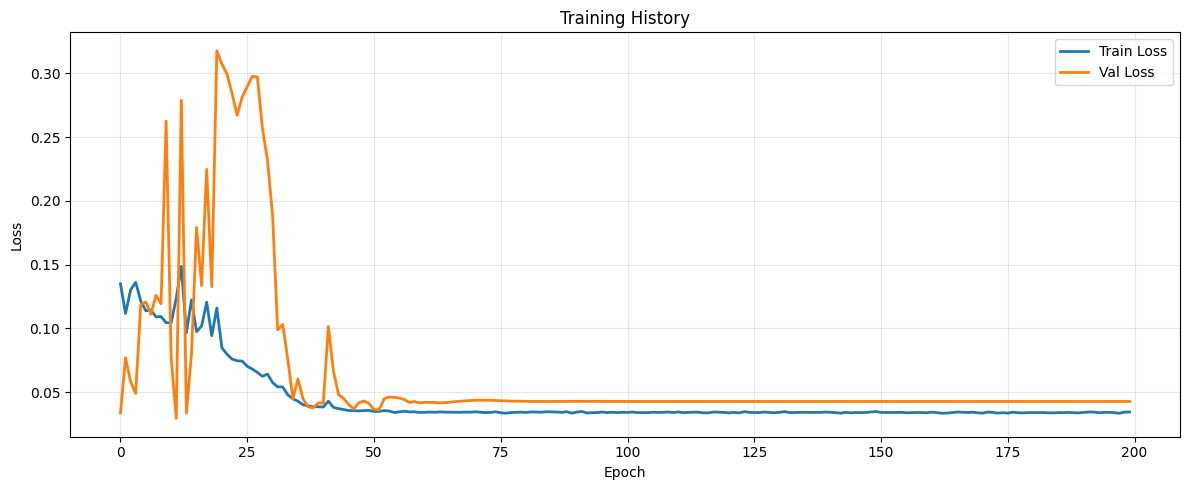

In [ ]:
utils.plot_training_history(train_losses, val_losses)

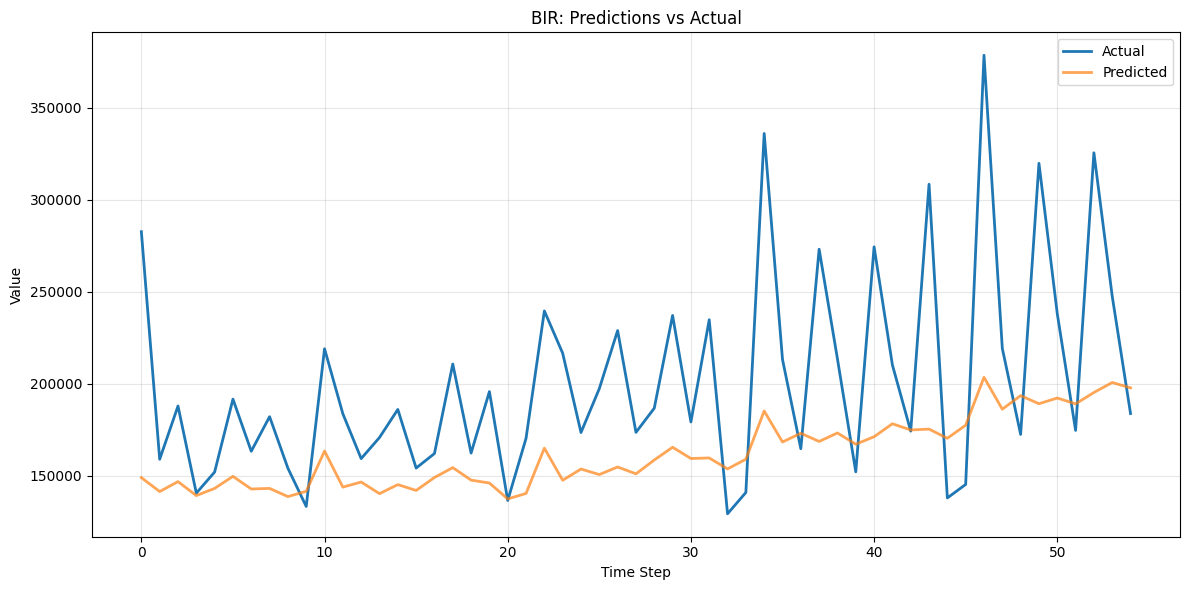

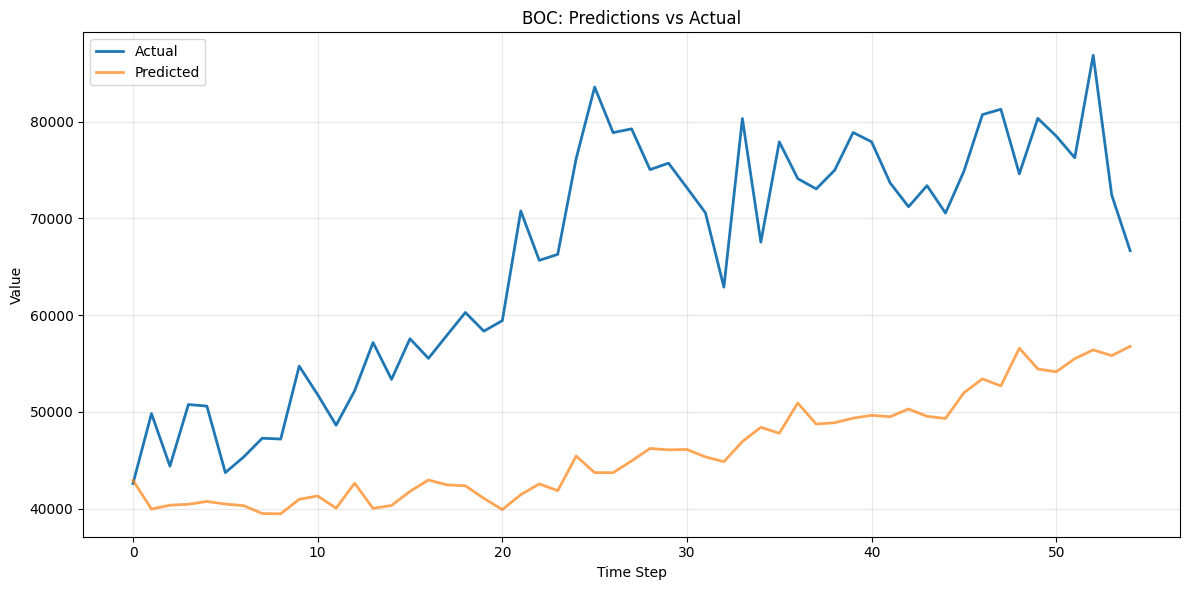

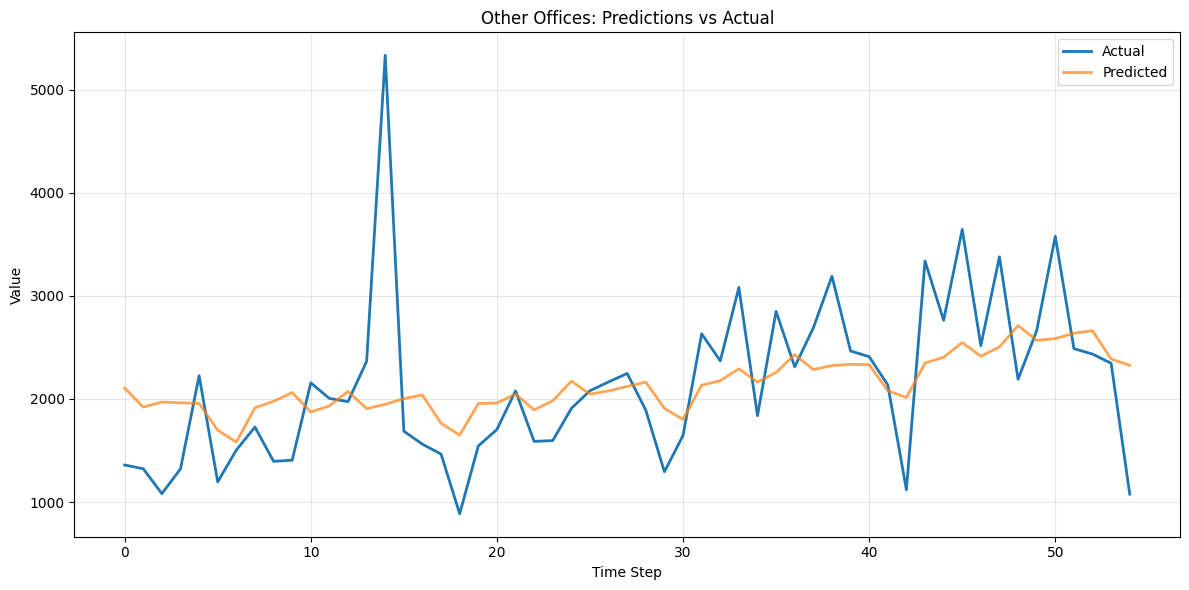

In [ ]:
utils.plot_test_predictions(test_preds, test_loader, args)